<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/Spot_Testing_26_12_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Logistic Regression:
        Advantages: Simple, interpretable, and fast.
        Considerations: Assumes a linear relationship between features and the log-odds of the response.

    Decision Trees:
        Advantages: Can capture complex relationships and interactions in the data.
        Considerations: Prone to overfitting; ensemble methods like Random Forests can help mitigate this.

    Random Forests:
        Advantages: Combines multiple decision trees to improve predictive performance and reduce overfitting.
        Considerations: Requires more computational resources than individual decision trees.

    Gradient Boosting (e.g., XGBoost, LightGBM):
        Advantages: Builds a series of weak learners to create a strong predictive model.
        Considerations: Sensitive to hyperparameter tuning but generally performs well.

    Support Vector Machines (SVM):
        Advantages: Effective in high-dimensional spaces; kernel trick can handle complex relationships.
        Considerations: Might be computationally expensive on large datasets.

    Neural Networks:
        Advantages: Can capture intricate patterns and relationships in data.
        Considerations: Requires a larger amount of data and computational resources; interpretability might be challenging.

    K-Nearest Neighbors (KNN):
        Advantages: Non-parametric and simple; can be effective for small datasets.
        Considerations: Sensitive to the choice of distance metric and k value.

    Ensemble Methods:
        Combining multiple models (e.g., bagging, boosting) can often result in improved predictive performance.

When working on a loan default prediction task, it's essential to preprocess your data appropriately, handle imbalanced classes, and perform feature engineering. Additionally, hyperparameter tuning and proper model evaluation (using metrics like precision, recall, F1-score, and ROC-AUC) are crucial for building an effective predictive model.

In [1]:
!pip install --pre pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.7/484.7 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.4 MB/s et

In [95]:
# Installed packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pycaret.classification as pyc
from pycaret.classification import *
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: ignored

In [96]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


# Preprocessing
Preprocessing the dataset for use for train/testing of algorythms

In [97]:
#Import dataset from GoogleDrive
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/clean_data.csv", index_col=0)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
1,21.0,9600.0,2.0,5.0,1.0,1.0,1000.0,11.14,0.10,0.0,2.0,0
2,25.0,9600.0,0.0,1.0,3.0,2.0,5500.0,12.87,0.57,0.0,3.0,1
3,23.0,65500.0,3.0,4.0,3.0,2.0,35000.0,15.23,0.53,0.0,2.0,1
4,24.0,54400.0,3.0,8.0,3.0,2.0,35000.0,14.27,0.55,1.0,4.0,1
5,21.0,9900.0,2.0,2.0,5.0,0.0,2500.0,7.14,0.25,0.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57.0,53000.0,0.0,1.0,4.0,2.0,5800.0,13.16,0.11,0.0,30.0,0
32577,54.0,120000.0,0.0,4.0,4.0,0.0,17625.0,7.49,0.15,0.0,19.0,0
32578,65.0,76000.0,3.0,3.0,2.0,1.0,35000.0,10.99,0.46,0.0,28.0,1
32579,56.0,150000.0,0.0,5.0,4.0,1.0,15000.0,11.48,0.10,0.0,26.0,0


In [6]:
df.isnull().sum()

Unnamed: 0                    0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [98]:
#initializing an object of class LabelEncoder
labelencoder= LabelEncoder()
#fitting and transforming the desired categorical column.
df['person_home_ownership'] = labelencoder.fit_transform(df['person_home_ownership'])
df['loan_intent'] = labelencoder.fit_transform(df['loan_intent'])
df['loan_grade'] = labelencoder.fit_transform(df['loan_grade'])
df['cb_person_default_on_file'] = labelencoder.fit_transform(df['cb_person_default_on_file'])

In [99]:
cols_to_norm = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','person_income','person_income','person_income']
df[cols_to_norm] = StandardScaler().fit_transform(df[cols_to_norm])

NameError: ignored

In [100]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [101]:
from sklearn.model_selection import train_test_split
# i.e. 70 % training dataset and 30 % test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, shuffle=True)

# TEST

In [49]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
1,-1.085359,-1.071942,2,0.055848,1,1,-1.359400,0.041283,-0.657826,0,-0.939438,0
2,-0.440148,-1.071942,0,-0.945704,3,2,-0.647472,0.579952,3.743601,0,-0.692901,1
3,-0.762753,-0.007532,3,-0.194540,3,2,4.019613,1.314783,3.369012,0,-0.939438,1
4,-0.601451,-0.218891,3,0.807012,3,2,4.019613,1.015869,3.556307,1,-0.446365,1
5,-1.085359,-1.066230,2,-0.695316,5,0,-1.122091,-1.204194,0.746885,0,-0.939438,1
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,4.721537,-0.245549,0,-0.945704,4,2,-0.600010,0.670249,-0.564179,0,5.963589,0
32577,4.237629,1.030220,0,-0.194540,4,0,1.270779,-1.095215,-0.189589,0,3.251686,0
32578,6.011959,0.192402,3,-0.444928,2,1,4.019613,-0.005422,2.713480,0,5.470516,1
32579,4.560235,1.601460,0,0.055848,4,1,0.855487,0.147148,-0.657826,0,4.977443,0


In [50]:
s = setup(df, target = 'loan_status', train_size = 0.7)

,Description,Value
0,Session id,3092
1,Target,loan_status
2,Target type,Binary
3,Original data shape,"(32408, 12)"
4,Transformed data shape,"(32408, 12)"
5,Transformed train set shape,"(22685, 12)"
6,Transformed test set shape,"(9723, 12)"
7,Numeric features,11
8,Preprocess,True
9,Imputation type,simple


In [51]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9360,0.9457,0.7249,0.9763,0.8318,0.7934,0.8069,3.6920
xgboost,Extreme Gradient Boosting,0.9351,0.9441,0.7373,0.9557,0.8323,0.7930,0.8033,0.2630
rf,Random Forest Classifier,0.9289,0.9279,0.7025,0.9621,0.8119,0.7694,0.7839,2.6510
gbc,Gradient Boosting Classifier,0.9231,0.9258,0.6922,0.9408,0.7973,0.7512,0.7649,2.3720
et,Extra Trees Classifier,0.9210,0.9209,0.6900,0.9311,0.7924,0.7449,0.7578,1.8070
ada,Ada Boost Classifier,0.8861,0.8980,0.6509,0.7914,0.7141,0.6438,0.6487,0.8010
knn,K Neighbors Classifier,0.8844,0.8572,0.6055,0.8188,0.6959,0.6265,0.6376,0.5160
dt,Decision Tree Classifier,0.8828,0.8379,0.7579,0.7211,0.7389,0.6634,0.6639,0.1180
lr,Logistic Regression,0.8447,0.8475,0.4650,0.7269,0.5668,0.4778,0.4957,0.9370
qda,Quadratic Discriminant Analysis,0.8435,0.8507,0.6650,0.6366,0.6503,0.5496,0.5499,0.0450


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

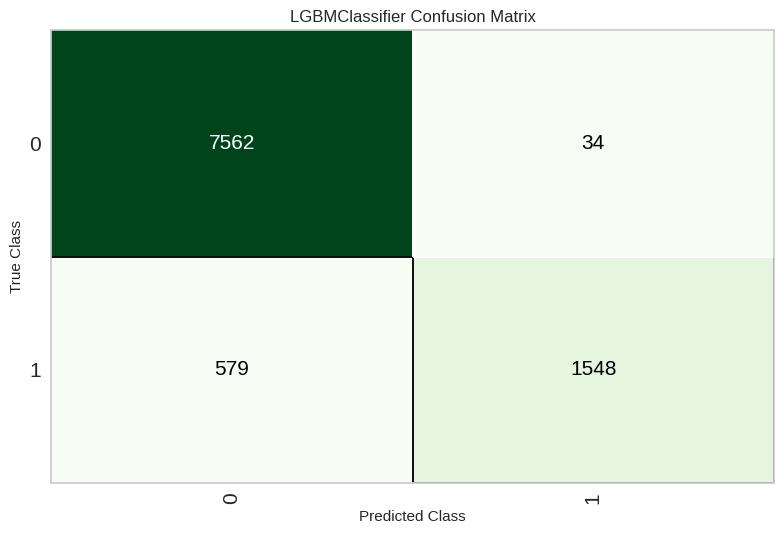

In [52]:
plot_model(best, plot = 'confusion_matrix')

In [55]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       n_estimators=100, n_jobs=None, oob_score=False,
                       random_state=None, verbose=0, warm_start=False)

In [56]:
y_pred = rf.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9309883780726114


In [58]:
recall = recall_score(y_test, y_pred)
print("recall:", recall)

recall: 0.7096926713947991


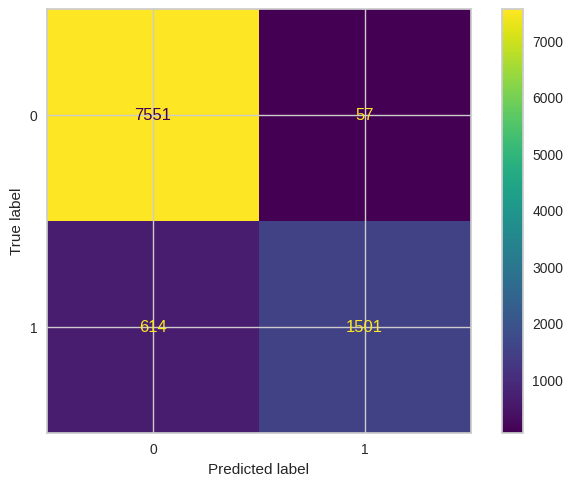

In [59]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

# Spot checking 5 algorythms

**Linear Regression**

# **Descition Tree**

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree

In [88]:
# Creating and training the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=20, max_depth=11)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=11, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       random_state=20, splitter='best')

In [89]:
# Making predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

In [80]:
# Evaluating the model (random_state=42, max_depth=11)
accuracy = accuracy_score(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
classification_rep = classification_report(y_test, y_pred_dt)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.92
Confusion Matrix:
[[7466  143]
 [ 609 1505]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7609
           1       0.91      0.71      0.80      2114

    accuracy                           0.92      9723
   macro avg       0.92      0.85      0.88      9723
weighted avg       0.92      0.92      0.92      9723



# **Random Forest**

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [109]:
# Creating and training the Random Forest Classifier with variations
# You can adjust the hyperparameters as needed
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=20, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       n_estimators=100, n_jobs=None, oob_score=False,
                       random_state=42, verbose=0, warm_start=False)

In [110]:
# Making predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

In [111]:
# Evaluating the model (n_estimators=100, max_depth=20)
accuracy = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
classification_rep = classification_report(y_test, y_pred_rf)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.93
Confusion Matrix:
[[7551   58]
 [ 619 1495]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      7609
           1       0.96      0.71      0.82      2114

    accuracy                           0.93      9723
   macro avg       0.94      0.85      0.89      9723
weighted avg       0.93      0.93      0.93      9723



In [101]:
# Evaluating the model (n_estimators=50, max_depth=10)
accuracy = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
classification_rep = classification_report(y_test, y_pred_rf)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.93
Confusion Matrix:
[[7562   47]
 [ 675 1439]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7609
           1       0.97      0.68      0.80      2114

    accuracy                           0.93      9723
   macro avg       0.94      0.84      0.88      9723
weighted avg       0.93      0.93      0.92      9723



# **Support Vector Machines**

In [1]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
# Creating and training the Support Vector Machines Classifier
# You can adjust the hyperparameters as needed
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train, y_train)

SVC(C=10.0, gamma='auto', random_state=42)

In [23]:
# Making predictions on the test set
y_pred_svm = svm_classifier.predict(X_test)

In [15]:
# Evaluating the model C = 1
accuracy = accuracy_score(y_test, y_pred_svm)
conf_matrix = confusion_matrix(y_test, y_pred_svm)
classification_rep = classification_report(y_test, y_pred_svm)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.80
Confusion Matrix:
[[7483   68]
 [1839  333]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      7551
           1       0.83      0.15      0.26      2172

    accuracy                           0.80      9723
   macro avg       0.82      0.57      0.57      9723
weighted avg       0.81      0.80      0.75      9723



# **K-Nearest Neighbour**

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [38]:
# Creating and training the k-Nearest Neighbors Classifier
# You can adjust the hyperparameters as needed
knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [39]:
# Making predictions on the test set
y_pred_knn = knn_classifier.predict(X_test)

In [40]:
# Evaluating the model k = 7
accuracy = accuracy_score(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
classification_rep = classification_report(y_test, y_pred_knn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.84
Confusion Matrix:
[[7059  492]
 [1105 1067]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90      7551
           1       0.68      0.49      0.57      2172

    accuracy                           0.84      9723
   macro avg       0.77      0.71      0.74      9723
weighted avg       0.82      0.84      0.83      9723



In [28]:
# Evaluating the model k = 5
accuracy = accuracy_score(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
classification_rep = classification_report(y_test, y_pred_knn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.83
Confusion Matrix:
[[7003  548]
 [1096 1076]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      7551
           1       0.66      0.50      0.57      2172

    accuracy                           0.83      9723
   macro avg       0.76      0.71      0.73      9723
weighted avg       0.82      0.83      0.82      9723



# **Naive Baise**

In [45]:
from sklearn.naive_bayes import GaussianNB

In [46]:
# Creating and training the Naive Bayes Classifier (Gaussian Naive Bayes for continuous features)
naive_bayes_classifier = GaussianNB()
naive_bayes_classifier.fit(X_train, y_train)

MultinomialNB()

In [47]:
# Making predictions on the test set
y_pred_nb = naive_bayes_classifier.predict(X_test)

In [48]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred_nb)
conf_matrix = confusion_matrix(y_test, y_pred_nb)
classification_rep = classification_report(y_test, y_pred_nb)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.66
Confusion Matrix:
[[4965 2586]
 [ 739 1433]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75      7551
           1       0.36      0.66      0.46      2172

    accuracy                           0.66      9723
   macro avg       0.61      0.66      0.61      9723
weighted avg       0.76      0.66      0.69      9723



# **XGboost**

In [49]:
from xgboost import XGBClassifier

In [50]:
# Creating and training the XGBoost Classifier
# You can adjust the hyperparameters as needed
xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [51]:
# Making predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

In [52]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
classification_rep = classification_report(y_test, y_pred_xgb)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.92
Confusion Matrix:
[[7462   89]
 [ 647 1525]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7551
           1       0.94      0.70      0.81      2172

    accuracy                           0.92      9723
   macro avg       0.93      0.85      0.88      9723
weighted avg       0.93      0.92      0.92      9723



# **Mulit-layer Perceptron**

In [53]:
from sklearn.neural_network import MLPClassifier

In [78]:
# Creating and training the Multi-layer Perceptron Classifier
# You can adjust the hyperparameters as needed
mlp_classifier = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=200, random_state=42)
mlp_classifier.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(12, 12, 6), random_state=42)

In [79]:
# Making predictions on the test set
y_pred_mlp = mlp_classifier.predict(X_test)

In [71]:
# Evaluating the model (hidden_layer_sizes=(16, 8), max_iter=200, random_state=42)
accuracy = accuracy_score(y_test, y_pred_mlp)
conf_matrix = confusion_matrix(y_test, y_pred_mlp)
classification_rep = classification_report(y_test, y_pred_mlp)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.84
Confusion Matrix:
[[7219  332]
 [1265  907]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      7551
           1       0.73      0.42      0.53      2172

    accuracy                           0.84      9723
   macro avg       0.79      0.69      0.72      9723
weighted avg       0.82      0.84      0.82      9723



In [62]:
# Evaluating the model (hidden_layer_sizes=(20, 10), max_iter=200, random_state=42)
accuracy = accuracy_score(y_test, y_pred_mlp)
conf_matrix = confusion_matrix(y_test, y_pred_mlp)
classification_rep = classification_report(y_test, y_pred_mlp)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.78
Confusion Matrix:
[[7551    0]
 [2158   14]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      7551
           1       1.00      0.01      0.01      2172

    accuracy                           0.78      9723
   macro avg       0.89      0.50      0.44      9723
weighted avg       0.83      0.78      0.68      9723



# Comparition

# Imbalance

There is imblance and this is cuasing an accuracy paradox therefore we decide to explore some techniques that can help improve the prediction

In [103]:
from imblearn.combine import *

In [105]:
smote = SMOTETomek(random_state=42)
X_train_over,y_train_over = smote.fit_resample(X_train,y_train)

In [106]:
# Creating and training the Random Forest Classifier with variations
# You can adjust the hyperparameters as needed
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_classifier.fit(X_train_over, y_train_over)

RandomForestClassifier(max_depth=20, random_state=42)

In [108]:
# Making predictions on the test set
y_pred_rf_over = rf_classifier.predict(X_test)

In [109]:
# Evaluating the model (n_estimators=100, max_depth=20)
accuracy = accuracy_score(y_test, y_pred_rf_over)
conf_matrix = confusion_matrix(y_test, y_pred_rf_over)
classification_rep = classification_report(y_test, y_pred_rf_over)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.90
Confusion Matrix:
[[7169  408]
 [ 569 1577]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7577
           1       0.79      0.73      0.76      2146

    accuracy                           0.90      9723
   macro avg       0.86      0.84      0.85      9723
weighted avg       0.90      0.90      0.90      9723



In [89]:
# Evaluating the model (n_estimators=100, max_depth=20)
accuracy = accuracy_score(y_test, y_pred_rf_smote)
conf_matrix = confusion_matrix(y_test, y_pred_rf_smote)
classification_rep = classification_report(y_test, y_pred_rf_smote)

print(f'Accuracy: {accuracy:.2f}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.90
Confusion Matrix:
[[7129  422]
 [ 530 1642]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7551
           1       0.80      0.76      0.78      2172

    accuracy                           0.90      9723
   macro avg       0.86      0.85      0.86      9723
weighted avg       0.90      0.90      0.90      9723



In [ ]:
s = setup(df, target = 'loan_status', train_size = 0.7)

In [ ]:
best = compare_models()